# Figure of Merit

Just a piece of code which computes the performance of the network on discrete datasets

In [61]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import avg_fidelity_loss, avg_norm_loss, mse_cyclic_2, loadData
import math

from dataGenNew import generate_random_function, generate_random_function_poly, Ugen, rand_En, rand_costheta, rand_phi, full_measure, full_measure_cart, compute_waveplate
from dataGenNew import rand_nx, compute_waveplate_cart, rand_optic
from dataGenNew import rand_ny, rand_nz

import tensorflow as tf
import pickle as pkl
from keras import backend as K
import time 


# Sidequest: Load the Dataset

In [62]:
fileName = '64by64_200_test_new.pkl'
X,y = loadData(fileName, 32, forTrain=False)


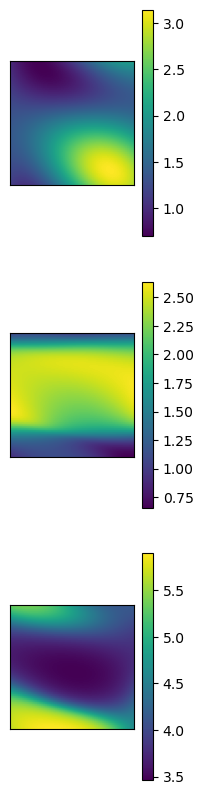

In [74]:
batchIndex = 10

a1 = y[batchIndex, :,:, 0]
a2 = y[batchIndex, :,:, 1]
a3 = y[batchIndex, :,:, 2]


fig, ax = plt.subplots(3,1, figsize=(2,10))

ax[0].imshow(a1) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(a2) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(a3) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)


# Add colorbars to subplots
cb1 = fig.colorbar(ax[0].imshow(a1), ax=ax[0])
cb2 = fig.colorbar(ax[1].imshow(a2), ax=ax[1])
cb3 = fig.colorbar(ax[2].imshow(a3), ax=ax[2])

# Make Subplots of Input Data

'\ncb1 = fig.colorbar(ax[0].imshow(X[:,:,0]), ax=ax[0])\ncb2 = fig.colorbar(ax[1].imshow(X[:,:,1]), ax=ax[1])\ncb3 = fig.colorbar(ax[2].imshow(X[:,:,2]), ax=ax[2])\ncb4 = fig.colorbar(ax[3].imshow(X[:,:,3]), ax=ax[3])\ncb5 = fig.colorbar(ax[4].imshow(X[:,:,4]), ax=ax[4])\n\n\n'

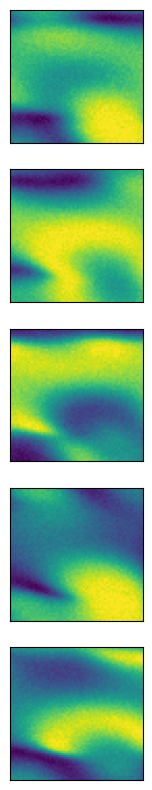

In [75]:
fig, ax = plt.subplots(5,1, figsize=(2,10))


ax[0].imshow(X[batchIndex,:,:,0]) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(X[batchIndex,:,:,1]) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(X[batchIndex,:,:,2]) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].imshow(X[batchIndex,:,:,3])
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].imshow(X[batchIndex,:,:,4])
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)

# Add colorbars to subplots

'''
cb1 = fig.colorbar(ax[0].imshow(X[:,:,0]), ax=ax[0])
cb2 = fig.colorbar(ax[1].imshow(X[:,:,1]), ax=ax[1])
cb3 = fig.colorbar(ax[2].imshow(X[:,:,2]), ax=ax[2])
cb4 = fig.colorbar(ax[3].imshow(X[:,:,3]), ax=ax[3])
cb5 = fig.colorbar(ax[4].imshow(X[:,:,4]), ax=ax[4])


'''


Load trained model 

In [2]:
# Load model checkpoint 
num_pix = 64

mol_64_ctop = '64Net_oneDim'
mol_64_five_64U = '64Net_allRand_five_64U'
mol_metalRules = '64Net_heavyMetal_enhanced'
mol_100k = '64Net_heavyMetal_100k_CPU'
mol_moreLayers = '64Net_heavyMetal_50k'
mol_50k_four = '64Net_heavyMetal_50k_four'

loaded_model = tf.keras.models.load_model(mol_50k_four, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss, 'mse_cyclic_2':mse_cyclic_2}, compile=True)


Functions to compute the fidelity of the process

In [3]:
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

Let's be fancy by defining a class that'll hold both the processes themselves, and their average fidelities!

In [4]:
class UnitaryProcess(): 
    
    def __init__ (self, input_meas, output_unitary, pred_unitary, fid):
        self.input_meas = input_meas
        self.output_unitary = output_unitary
        self.fid = fid
        self.pred_unitary = pred_unitary
    
    def get_inputMeas(self):
        return self.input_meas
    
    def get_outputUnitary(self):
        return self.output_unitary
    
    def get_fid(self):
        return self.fid
    
    def get_predUnitary(self):
        return self.pred_unitary
        

Now we prompt the neural network to make predictions. Here, the data is generated directly in the evaluation process.

In [12]:
n_coeff_high = 6
n_coeff_low = 0
res = num_pix
maxAng = 5
noise = 0.01
stateNoise = 0.0
num_of_process = 5

rand_func = lambda x,y: np.random.randint(low=x, high=y)

samples = []

for ii in range(num_of_process):
    
    X = np.empty((num_pix,num_pix,5))
    y = np.empty((num_pix,num_pix,3))

    a1=rand_En(rand_func(n_coeff_low,n_coeff_high), rand_func(n_coeff_low,n_coeff_high), res, maxAng) 
    #obtain cartesian coordinates
    
    nx = rand_nx(rand_func(n_coeff_low,n_coeff_high), rand_func(n_coeff_low,n_coeff_high), res, maxAng)
    ny = rand_ny(rand_func(n_coeff_low,n_coeff_high), rand_func(n_coeff_low,n_coeff_high), res, maxAng)
    nz = rand_nz(rand_func(n_coeff_low,n_coeff_high), rand_func(n_coeff_low,n_coeff_high), res, maxAng)
    
    # make sure that the processes are normalized 
        
    norm = np.sqrt(nx**2 + ny**2 + nz**2)
    nx = nx/norm 
    ny = ny/norm 
    nz = nz/norm 
    
    #convert to spherical coordinates


    a2=np.arccos(nz)
    a3=np.arctan2(ny, nx)  
    for i in range(res):
        for j in range(res):
            if a3[i,j] < 0:
                a3[i,j] += 2*np.pi

    #a3=rand_phi(n_coeff,res,maxAng) 
    
    print(a2[0,0]>np.pi/2)
    
    if a2[0,0]>np.pi/2: # make sure the first pixel has nz>0
        a2=(np.pi-a2)
        print("WAH")
        
    print(a2[0,0]>np.pi/2)
    # Now, perform measurement
    full_meas = full_measure(a1,a2,a3,res,noise, stateNoise)
    full_meas_enhance = tf.expand_dims(full_meas, axis=0)
    
    y_pred=loaded_model.predict(full_meas_enhance)
    
    # Polar coordinate reconstruction
    print("it is time")
    En_vect=y_pred[0,:,:,0]
    nx_vect=np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
    ny_vect=np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
    nz_vect=np.cos(y_pred[0,:,:,1])
    
    nx=np.sin(a2)*np.cos(a3)
    ny=np.sin(a2)*np.sin(a3)
    nz=np.cos(a2)
    
    Fvals = np.zeros([num_pix,num_pix])
    
    # compute the fidelity
    for i in range(num_pix):
        for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(a1[i,j],nx[i,j],ny[i,j],nz[i,j])
            Fvals[i,j]=fidelity(netU,thU)
    
    print(np.mean(Fvals))
    
    # store samples in list as a unitaryProcess object 
    
    X[:,:,:] = full_meas
    y[:,:,0] = a1
    y[:,:,1] = a2
    y[:,:,2] = a3
    
    unitProcess = UnitaryProcess(input_meas=X, output_unitary=y, fid=np.mean(Fvals), pred_unitary=y_pred)
    
    samples.append(unitProcess)
    print(ii)
            
    

False
False
1/1 [==============================] - 0s 458ms/step
it is time
0.9665246555275466
0
True
WAH
False
1/1 [==============================] - 0s 472ms/step
it is time
0.9646589594721087
1
True
WAH
False
1/1 [==============================] - 0s 430ms/step
it is time
0.6375846778265047
2
True
WAH
False
1/1 [==============================] - 0s 474ms/step
it is time
0.8987532991619911
3
True
WAH
False
1/1 [==============================] - 0s 470ms/step
it is time
0.9226615865318186
4


In [13]:
fids = [samples[ii].get_fid() for ii in range(len(samples))]

In [14]:
suspect_indices = []

for ii in range(len(samples)):
    if (samples[ii].get_fid() < 0.99):
        suspect_indices.append(ii)


In [15]:
suspect_indices

[0, 1, 2, 3, 4]

Let's take a look at these curious samples.

In [18]:
sample_index = 1
suspect_index = suspect_indices[sample_index]

y_act = samples[suspect_index].get_outputUnitary()

y_pred = samples[suspect_index].get_predUnitary()
fid = samples[suspect_index].get_fid()
                                

Plot da samples

0.9646589594721087


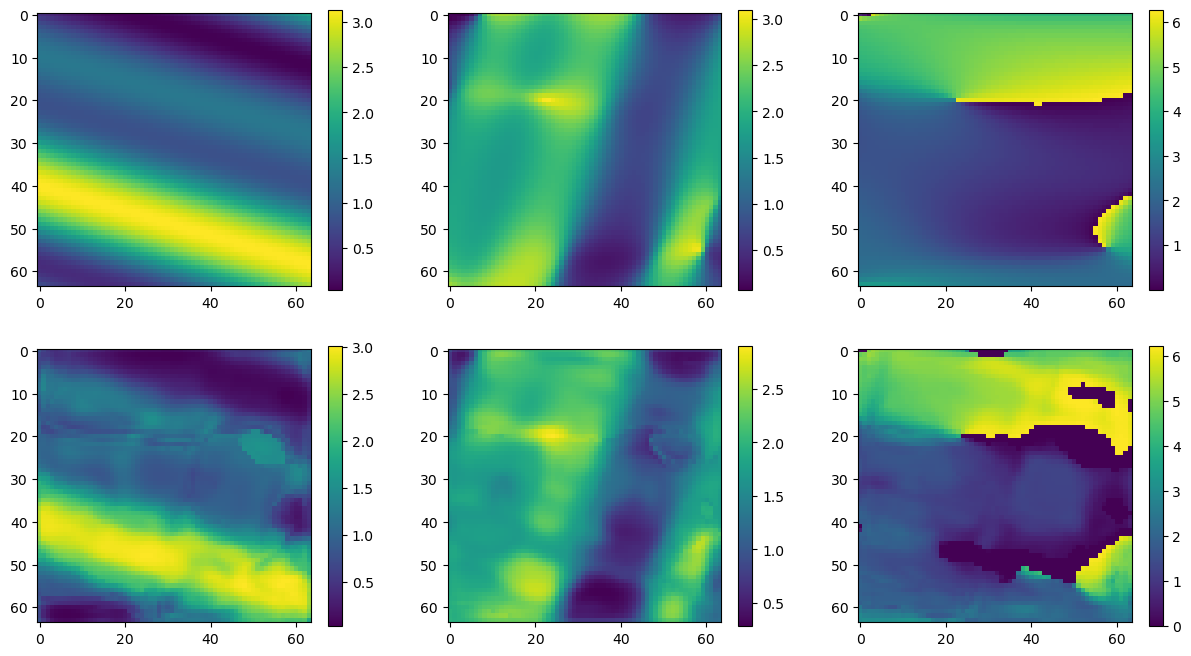

In [19]:
fig, ax = plt.subplots(2,3, figsize=(15,8))


c = ax[0,0].imshow(y_act[:,:,0])
cbar = fig.colorbar(c, ax=ax[0,0])
c2 = ax[1,0].imshow(y_pred[0,:,:,0])
cbar = fig.colorbar(c2, ax=ax[1,0])
c3 = ax[0,1].imshow(y_act[:,:,1])
cbar = fig.colorbar(c3, ax=ax[0,1])
c4 = ax[1,1].imshow(y_pred[0,:,:,1])
cbar = fig.colorbar(c4, ax=ax[1,1])
c5 = ax[0,2].imshow(y_act[:,:,2])
cbar = fig.colorbar(c5, ax=ax[0,2])
c6 = ax[1,2].imshow(y_pred[0,:,:,2])
cbar = fig.colorbar(c6, ax=ax[1,2])
print(fid)


In [46]:
# Polar coordinate reconstruction
print("it is time")
En_vect=y_pred[0,:,:,0]
nx_vect=np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_vect=np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_vect=np.cos(y_pred[0,:,:,1])

a1=y_act[:,:,0]
nx=np.sin(y_act[:,:,1])*np.cos(y_act[:,:,2])
ny=np.sin(y_act[:,:,1])*np.sin(y_act[:,:,2])
nz=np.cos(y_act[:,:,1])
    
Fvals = np.zeros([num_pix,num_pix])

# compute the fidelity
for i in range(num_pix):
    for j in range(num_pix):
        netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
        thU=op_par(a1[i,j],nx[i,j],ny[i,j],nz[i,j])
        Fvals[i,j]=fidelity(netU,thU)

print(np.mean(Fvals))

it is time
0.7107560301287166


Plot the histogram

(array([ 1.,  1.,  0.,  0.,  1.,  2.,  1.,  1.,  0.,  1.,  2.,  0.,  2.,
         2.,  0.,  2.,  1.,  2.,  1.,  1.,  2.,  3.,  2.,  4.,  8.,  6.,
         5., 12., 30.,  7.]),
 array([0.24955308, 0.27355953, 0.29756598, 0.32157243, 0.34557888,
        0.36958533, 0.39359178, 0.41759823, 0.44160468, 0.46561113,
        0.48961758, 0.51362403, 0.53763048, 0.56163693, 0.58564338,
        0.60964983, 0.63365628, 0.65766273, 0.68166918, 0.70567563,
        0.72968208, 0.75368853, 0.77769498, 0.80170144, 0.82570789,
        0.84971434, 0.87372079, 0.89772724, 0.92173369, 0.94574014,
        0.96974659]),
 <BarContainer object of 30 artists>)

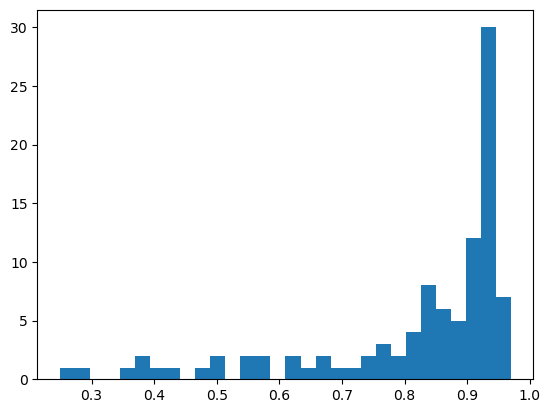

In [22]:
plt.hist(fids, bins=30)

Alternatively, we load an external dataset

In [12]:
fids = []
samples = []
noise = 0.01
stateNoise = 0.0
num_of_process = 5


for ii in range(num_of_process):
    a1 = y[ii,:,:,0]
    a2 = y[ii,:,:,1]
    a3 = y[ii,:,:,2]
    
    # Compute cartesian coordinates 
    En_th_mat=a1
    nx_th_mat=np.sin(a2)*np.cos(a3)
    ny_th_mat=np.sin(a2)*np.sin(a3)
    nz_th_mat=np.cos(a2)
    
    full_meas_enhance = tf.expand_dims(X[ii,:,:,:], axis=0)
    
    y_pred=loaded_model.predict(full_meas_enhance)
    
    # Polar coordinate reconstruction
    print("it is time")
    En_vect=y_pred[0,:,:,0]
    nx_vect=np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
    ny_vect=np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
    nz_vect=np.cos(y_pred[0,:,:,1])
    
    Fvals = np.zeros([num_pix,num_pix])
    
    # compute the fidelity
    for i in range(num_pix):
        for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(En_th_mat[i,j],nx_th_mat[i,j],ny_th_mat[i,j],nz_th_mat[i,j])
            Fvals[i,j]=fidelity(netU,thU)
    
    print(np.mean(Fvals))
    fids.append(np.mean(Fvals))

    unitProcess = UnitaryProcess(input_meas=X[ii,:,:,:], output_unitary=y[ii,:,:,:], fid=np.mean(Fvals), pred_unitary=y_pred)
    samples.append(unitProcess)
    
    

1/1 [==============================] - 1s 768ms/step
it is time
0.2678152462870208
1/1 [==============================] - 1s 671ms/step
it is time
0.7415988436708645
1/1 [==============================] - 1s 999ms/step
it is time
0.28195094078599625
1/1 [==============================] - 1s 831ms/step
it is time
0.18825282786358158
1/1 [==============================] - 1s 900ms/step
it is time
0.22773945770158427


In [36]:
sample = samples[2].get_predUnitary()
sampleTheory = samples[2].get_outputUnitary()


En_vect = sample[0,:,:,0]
nx_vect = np.sin(sample[0,:,:,1])*np.cos(sample[0,:,:,2])
ny_vect = np.sin(sample[0,:,:,1])*np.sin(sample[0,:,:,2])
nz_vect = np.cos(sample[0,:,:,1])


En_th_mat = sampleTheory[:,:,0]
a2 = sampleTheory[:,:,1]
a3 = sampleTheory[:,:,2]

nx_th_mat = np.sin(a2)*np.cos(a3)
ny_th_mat = np.sin(a2)*np.sin(a3)
nz_th_mat = np.cos(a2)

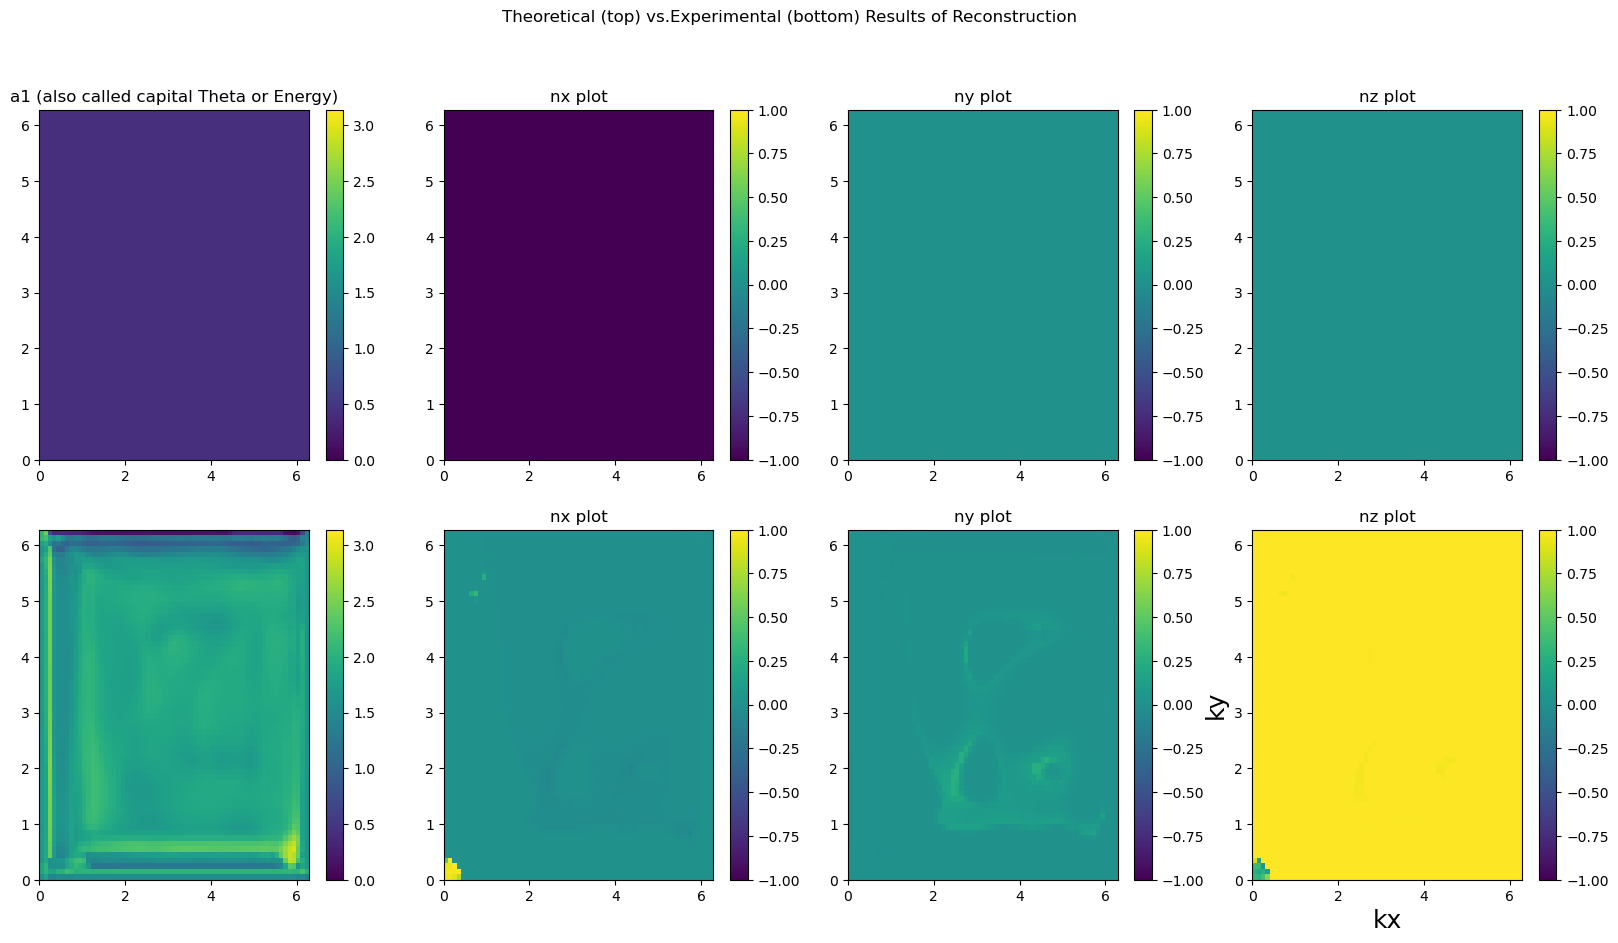

In [37]:
# Transpose the matrix

En_th_t = np.transpose(En_th_mat)
nx_th_t = np.transpose(nx_th_mat)
ny_th_t = np.transpose(ny_th_mat)
nz_th_t = np.transpose(nz_th_mat)

# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(2,4,figsize=(20, 10))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical (top) vs.Experimental (bottom) Results of Reconstruction')

c = ax[0,0].pcolormesh(x, y, En_th_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0,0])

c2 = ax[0,1].pcolormesh(x, y, nx_th_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[0,1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[0,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[0,1])

c3 = ax[0,2].pcolormesh(x, y, ny_th_t[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[0,2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[0,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[0,2])

c4 = ax[0,3].pcolormesh(x, y, nz_th_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[0,3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[0,3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[0,3])

c5 = ax[1,0].pcolormesh(x, y,  En_vect[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0,0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0,0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[1,0])

c6 = ax[1,1].pcolormesh(x, y,  nx_vect[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1,1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1,1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1,1])

c7 = ax[1,2].pcolormesh(x, y,  ny_vect[:-1, :-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[1,2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[1,2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[1,2])

c8 = ax[1,3].pcolormesh(x, y, nz_vect[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[1,3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[1,3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[1,3])

Now compute the mean value of fids, as the figure of merit

In [ ]:
print(np.mean(fids))
meanFids = np.mean(fids)
varFids  = np.var(fids)

# Plot the different average fidelities

In [ ]:
avgFids = [97.5, 93.78, 90.08, 86.73, 83.95, 82.79]
coeffs = [1,2,3,4,5,6]

plt.plot(coeffs, avgFids)
plt.scatter(coeffs, avgFids)
plt.title('Average Fidelity vs. Number of Fourier Coefficients (100 Processes)')
plt.xlabel('Number of Fourier Coefficients')
plt.ylabel('Average Fidelity')

# Plot Error Bars

In [ ]:
avgFids = [79.9, 77.5, 77.2]
variances = [6, 3, 4]
coeffs = ['(x=1, y=0)', '(x=1, y=1)', '(x=3, y=0)']


plt.bar(coeffs, avgFids, yerr=variances, capsize=4)

plt.ylabel('Average Fidelity')
plt.xlabel('Number of Coefficents')
plt.ylim(0,100)